In [1]:
import xarray as xr

In [2]:
ds = xr.open_dataset("../data/experiment/data/datastore.interior.domain03.zarr", engine="zarr")

In [3]:
del ds.attrs['creation_config']

In [5]:
import matplotlib.pyplot as plt

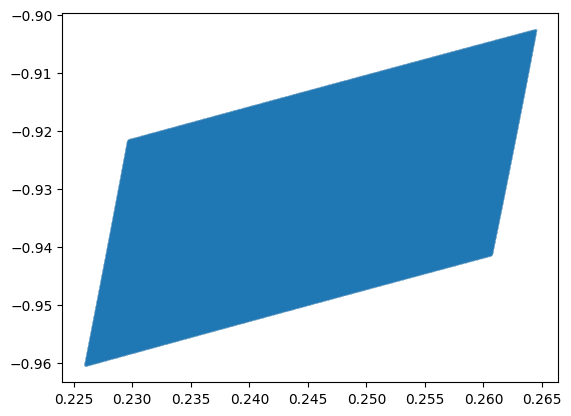

In [6]:
plt.scatter(ds.clat, ds.clon, s=0.01)

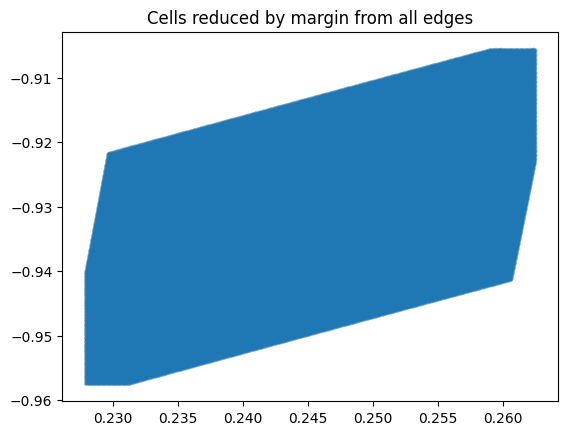

In [7]:
# Define margin as a fraction of the range (e.g., 5%)
margin_frac = 0.05

# Get min/max for lat/lon
lat_min, lat_max = ds.clat.min().item(), ds.clat.max().item()
lon_min, lon_max = ds.clon.min().item(), ds.clon.max().item()

# Calculate margin values
lat_margin = (lat_max - lat_min) * margin_frac
lon_margin = (lon_max - lon_min) * margin_frac

# Create mask for cells not within margin of any edge
mask = (
    (ds.clat > lat_min + lat_margin) & (ds.clat < lat_max - lat_margin) &
    (ds.clon > lon_min + lon_margin) & (ds.clon < lon_max - lon_margin)
)

# Filtered coordinates
clat_inner = ds.clat.where(mask, drop=True)
clon_inner = ds.clon.where(mask, drop=True)

# Plot reduced shape
plt.figure()
plt.scatter(clat_inner, clon_inner, s=0.01)
plt.title("Cells reduced by margin from all edges")
plt.show()

/tmp/ipykernel_876998/1696138564.py:17: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = vectorized.contains(inner_polygon, ds.clon.values, ds.clat.values)


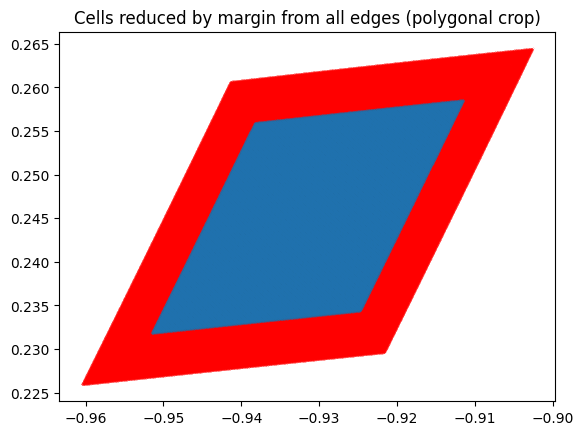

In [15]:
import numpy as np
from shapely.geometry import MultiPoint, Polygon
from shapely.ops import unary_union

# 1. Get all points as (lon, lat) pairs
points = np.column_stack([ds.clon.values.ravel(), ds.clat.values.ravel()])

# 2. Compute convex hull (or use actual boundary if available)
hull = MultiPoint(points).convex_hull

# 3. Shrink polygon by margin (buffer with negative value)
margin = 0.005  # adjust as needed (in degrees)
inner_polygon = hull.buffer(-margin)

# 4. Mask points inside the shrunken polygon
from shapely import vectorized
mask = vectorized.contains(inner_polygon, ds.clon.values, ds.clat.values)

# 5. Filter coordinates
clon_inner = ds.clon.values[mask]
clat_inner = ds.clat.values[mask]

# 6. Plot result
plt.figure()
plt.scatter(ds.clon, ds.clat, s=0.01, color='red')
plt.scatter(clon_inner, clat_inner, s=0.01)
plt.title("Cells reduced by margin from all edges (polygonal crop)")
plt.show()